# ESG Greenwashing Dataset Analysis


This notebook includes:
- Exploratory Data Analysis (EDA)
- Correlation Analysis
- Chi-Square Test
- ANOVA
- T-Test
- Time-Series Analysis
- Visualization


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import chi2_contingency, f_oneway, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# 2. Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv')

df.head()


,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
0,2010,ExxonMobil,XOM,Energy,USA,393.8,119.31,9.45,1123.35,128.76,NaN,0.30,27.7,D,No,No,Yes,Yes,0
1,2011,ExxonMobil,XOM,Energy,USA,390.7,111.91,8.56,976.85,120.47,-6.20,0.29,31.5,C,No,No,No,No,0
2,2012,ExxonMobil,XOM,Energy,USA,373.3,119.87,9.73,1210.04,129.60,7.11,0.32,30.9,C,No,No,No,No,0
3,2013,ExxonMobil,XOM,Energy,USA,396.5,110.06,8.76,1020.99,118.82,-8.18,0.28,32.3,B,No,No,Yes,Yes,0
4,2014,ExxonMobil,XOM,Energy,USA,381.1,115.06,10.49,1021.43,125.55,4.54,0.30,33.1,B-,No,No,No,No,0


# 3. Dataset Overview

In [3]:
print("Shape of Dataset:", df.shape)

df.info()


Shape of Dataset: (450, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             450 non-null    int64  
 1   company                          450 non-null    object 
 2   ticker                           450 non-null    object 
 3   sector                           450 non-null    object 
 4   country                          450 non-null    object 
 5   revenue_usd_bn                   450 non-null    float64
 6   scope1_emissions_mt_co2e         450 non-null    float64
 7   scope2_emissions_mt_co2e         450 non-null    float64
 8   scope3_emissions_mt_co2e         450 non-null    float64
 9   total_s1_s2_mt_co2e              450 non-null    float64
 10  yoy_scope1_change_pct            420 non-null    float64
 11  carbon_intensity_tco2e_per_musd  450 non-null    float64

# 4. Missing Values

In [4]:
df.isnull().sum()


year                                0
company                             0
ticker                              0
sector                              0
country                             0
revenue_usd_bn                      0
scope1_emissions_mt_co2e            0
scope2_emissions_mt_co2e            0
scope3_emissions_mt_co2e            0
total_s1_s2_mt_co2e                 0
yoy_scope1_change_pct              30
carbon_intensity_tco2e_per_musd     0
esg_score_0_100                     0
cdp_climate_score                   0
net_zero_target_set                 0
sbti_committed                      0
emissions_disclosed                 0
third_party_verified                0
greenwashing_flag                   0
dtype: int64

# 5. Descriptive Statistics



In [5]:
df.describe()


,year,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,greenwashing_flag
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,420.000000,450.000000,450.000000,450.000000
mean,2017.000000,93.835556,49.125222,5.007556,195.983956,54.132778,-2.793119,1.289956,56.824222,0.144444
std,4.325302,108.950919,41.968649,8.532921,268.645298,48.447366,5.750636,1.627213,17.026848,0.351931
min,2010.000000,2.900000,0.890000,0.220000,2.680000,1.120000,-18.410000,0.010000,24.000000,0.000000
25%,2013.000000,20.525000,12.587500,1.212500,17.480000,13.570000,-6.420000,0.180000,44.225000,0.000000
50%,2017.000000,50.050000,41.265000,2.560000,47.100000,44.340000,-2.805000,0.365000,55.850000,0.000000
75%,2021.000000,94.775000,73.735000,4.855000,342.772500,77.452500,0.860000,2.070000,67.150000,0.000000
max,2024.000000,453.700000,179.100000,47.560000,1210.040000,224.410000,15.180000,8.090000,100.000000,1.000000


# 6. Correlation Analysis


In [6]:
corr = df.corr(numeric_only=True)

corr


,year,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,greenwashing_flag
year,1.000000,0.033312,-0.149148,-0.049553,-0.039518,-0.137930,0.002308,-0.178761,0.338514,0.030725
revenue_usd_bn,0.033312,1.000000,0.300928,0.114649,0.862707,0.280879,0.104541,-0.406481,-0.155003,0.058526
scope1_emissions_mt_co2e,-0.149148,0.300928,1.000000,0.716207,0.508499,0.992417,0.025859,0.474520,-0.229516,0.047591
scope2_emissions_mt_co2e,-0.049553,0.114649,0.716207,1.000000,0.434290,0.796558,0.104562,0.207055,-0.246011,-0.047696
scope3_emissions_mt_co2e,-0.039518,0.862707,0.508499,0.434290,1.000000,0.516989,0.210566,-0.216591,-0.419270,-0.009458
total_s1_s2_mt_co2e,-0.137930,0.280879,0.992417,0.796558,0.516989,1.000000,0.040955,0.447532,-0.242153,0.032826
yoy_scope1_change_pct,0.002308,0.104541,0.025859,0.104562,0.210566,0.040955,1.000000,-0.046967,-0.241581,0.418934
carbon_intensity_tco2e_per_musd,-0.178761,-0.406481,0.474520,0.207055,-0.216591,0.447532,-0.046967,1.000000,-0.150826,-0.048097
esg_score_0_100,0.338514,-0.155003,-0.229516,-0.246011,-0.419270,-0.242153,-0.241581,-0.150826,1.000000,0.182315
greenwashing_flag,0.030725,0.058526,0.047591,-0.047696,-0.009458,0.032826,0.418934,-0.048097,0.182315,1.000000


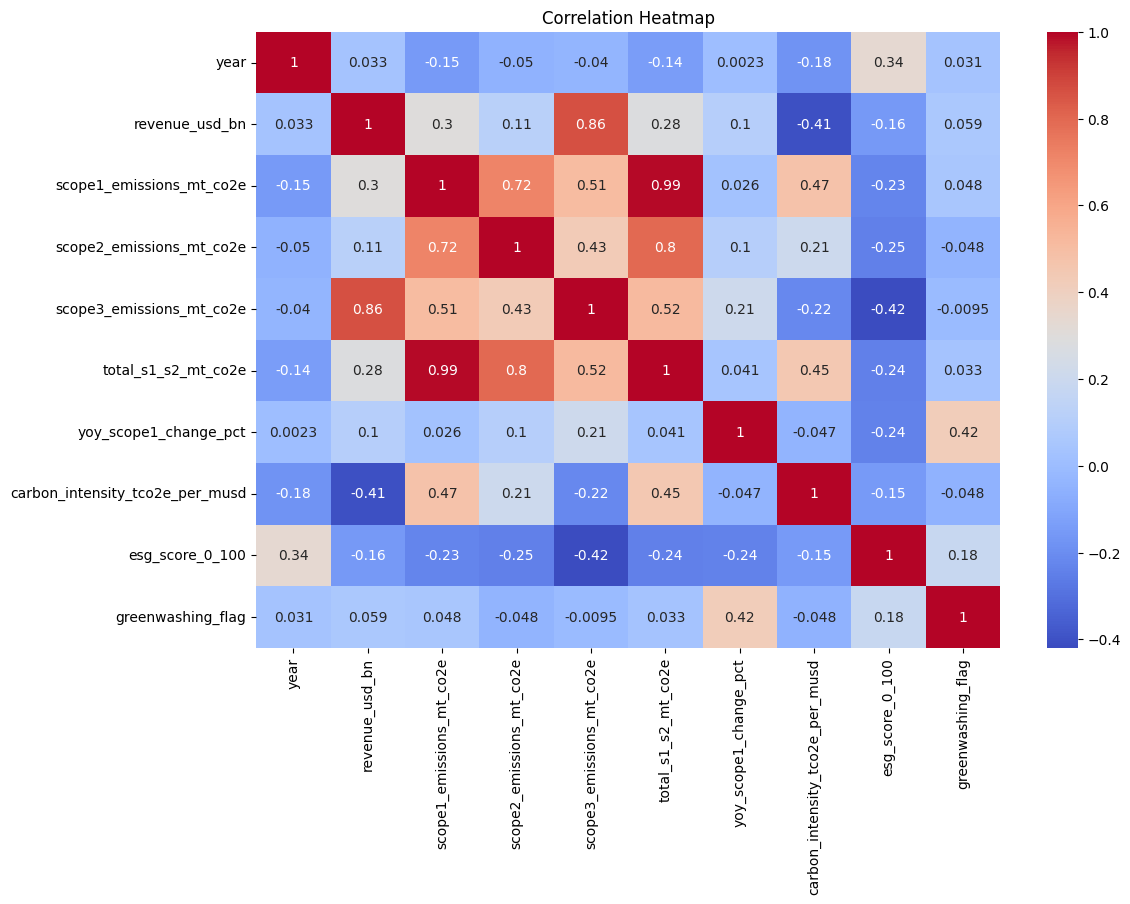

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# 7. Distribution of ESG Scores

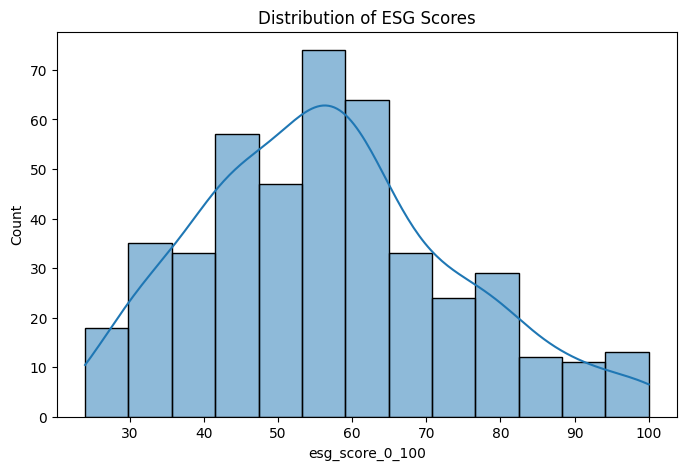

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['esg_score_0_100'], kde=True)
plt.title("Distribution of ESG Scores")
plt.show()


# 8. Sector-wise ESG Score Comparison


In [9]:
energy = df[df['sector'] == 'Energy']['esg_score_0_100']
utilities = df[df['sector'] == 'Utilities']['esg_score_0_100']
industrials = df[df['sector'] == 'Industrials']['esg_score_0_100']

anova_result = f_oneway(energy, utilities, industrials)

print("ANOVA Result:")
print(anova_result)


ANOVA Result:
F_onewayResult(statistic=np.float64(60.791906564272026), pvalue=np.float64(4.437746836905978e-24))


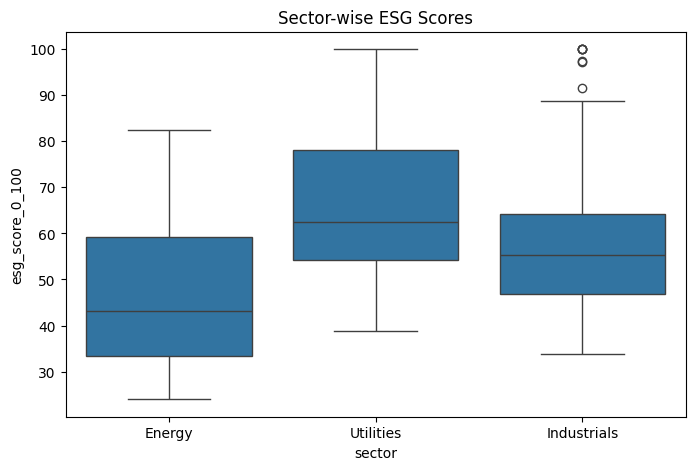

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sector', y='esg_score_0_100', data=df)
plt.title("Sector-wise ESG Scores")
plt.show()


# 9. T-Test

## Compare ESG scores between companies:
- With Net-Zero Target
- Without Net-Zero Target


In [11]:
from scipy.stats import ttest_ind
import pandas as pd

# Convert to numeric
df['esg_score_0_100'] = pd.to_numeric(df['esg_score_0_100'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['net_zero_target_set', 'esg_score_0_100'])

# Create groups
group1 = df[df['net_zero_target_set'] == 1]['esg_score_0_100']
group2 = df[df['net_zero_target_set'] == 0]['esg_score_0_100']

# Print sample sizes
print("Group 1 Size:", len(group1))
print("Group 2 Size:", len(group2))

# Check minimum sample size
if len(group1) < 2 or len(group2) < 2:
    print("\nError: One of the groups has fewer than 2 samples.")
    print("T-test cannot be performed.")
else:
    # Perform Welch's T-Test
    ttest_result = ttest_ind(group1, group2, equal_var=False)

    print("\nT-Test Result:")
    print(ttest_result)

Group 1 Size: 0
Group 2 Size: 0

Error: One of the groups has fewer than 2 samples.
T-test cannot be performed.


# 10. Chi-Square Test

### Example:
Greenwashing vs Third-Party Verification


In [12]:
contingency_table = pd.crosstab(
    df['greenwashing_flag'],
    df['third_party_verified']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)


Chi-Square Statistic: 2.115389402235615
P-value: 0.14582495803668816


# 11. Time-Series Analysis

## ESG Trend Over Time


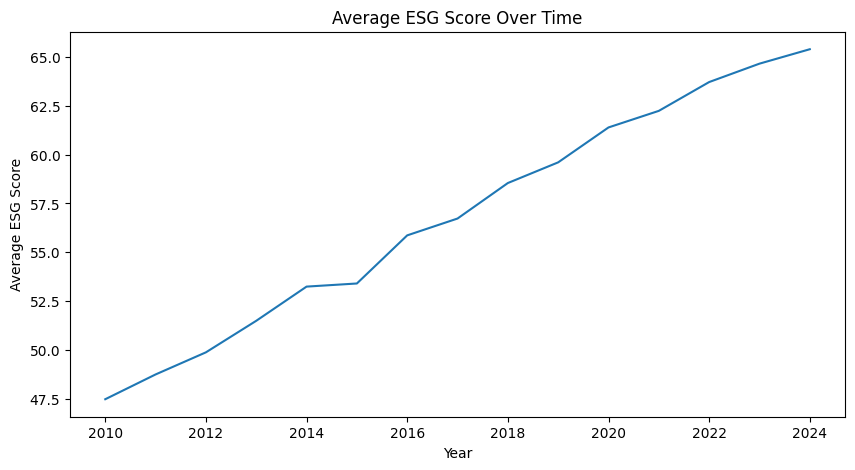

In [13]:
yearly_esg = df.groupby('year')['esg_score_0_100'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_esg['year'], yearly_esg['esg_score_0_100'])
plt.title("Average ESG Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average ESG Score")
plt.show()


# 12. Outlier Detection

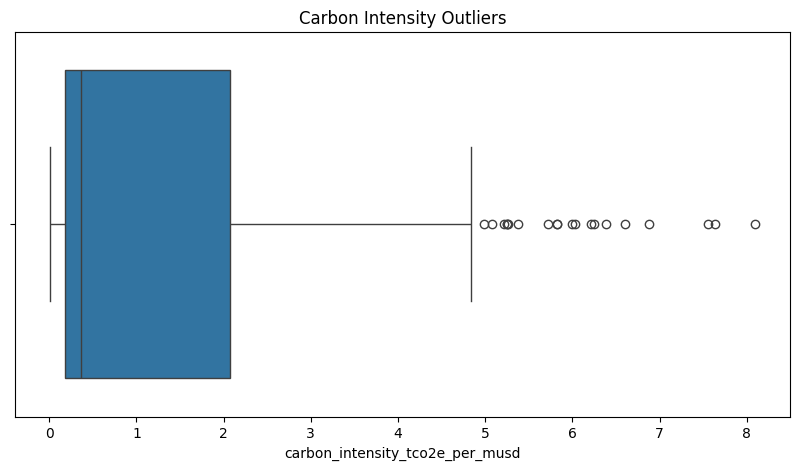

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['carbon_intensity_tco2e_per_musd'])
plt.title("Carbon Intensity Outliers")
plt.show()


# Conclusion

This dataset is best suited for:
- ESG Analysis
- Greenwashing Detection
- Correlation Analysis
- Chi-Square Testing
- Logistic Regression
- Time-Series Analysis
